In [43]:
import os
import sys
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def _find_repo_root(marker="requirements.txt"):
    path = os.getcwd()
    while True:
        if os.path.exists(os.path.join(path, marker)):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise FileNotFoundError(
                f"Could not locate repo root (looked for {marker})"
            )
        path = parent

REPO_ROOT = _find_repo_root()

sys.path.insert(0, REPO_ROOT)

In [44]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [45]:
df = pd.read_csv(
    os.path.join(REPO_ROOT, "data/raw/diabetes.csv")
)

In [46]:
batch_size = len(df) // 10

batches = []

for i in range(10):

    start = i * batch_size

    if i == 9:
        batch = df.iloc[start:]

    else:
        batch = df.iloc[start:start + batch_size]

    batches.append(batch)

print("Number of batches:", len(batches))

Number of batches: 10


In [47]:
cols_with_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

results = []
all_true = []
all_pred = []
all_future = []

thresholds_to_try = [0.3, 0.4, 0.5, 0.6, 0.7]

for i in range(3, 8):

    # Model trains on everything up to (but not including) the most recent
    # seen batch. That most recent batch (batches[i-1]) is held out from
    # training and used ONLY to pick the threshold. The evaluation batch
    # (batches[i]) is never touched until after the threshold is fixed --
    # this replaces the earlier version, which picked the threshold by
    # scoring F1 directly against the evaluation batch's own labels.
    train_batches = batches[:i - 1]
    val_batch = batches[i - 1]
    future_batch = batches[i]

    train_df = pd.concat(train_batches)

    X_train = train_df.drop("Outcome", axis=1)
    y_train = train_df["Outcome"]

    X_val = val_batch.drop("Outcome", axis=1)
    y_val = val_batch["Outcome"]

    X_future = future_batch.drop("Outcome", axis=1)
    y_future = future_batch["Outcome"]

    # Median-impute Pima's biologically-impossible zeros, fit on the
    # training batches only, applied to the validation and future batches.
    for col in cols_with_missing:
        median_value = X_train.loc[X_train[col] != 0, col].median()
        X_train[col] = X_train[col].replace(0, median_value)
        X_val[col] = X_val[col].replace(0, median_value)
        X_future[col] = X_future[col].replace(0, median_value)

    scaler = MinMaxScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_future = scaler.transform(X_future)

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        X_train,
        y_train,
        epochs=20,
        verbose=0
    )

    # Select the threshold using the held-out validation batch ONLY --
    # this batch was excluded from training but is not the evaluation set.
    y_val_prob = model.predict(X_val, verbose=0).flatten()

    best_f1 = -1
    threshold = 0.5
    for t in thresholds_to_try:
        y_val_pred = (y_val_prob >= t).astype(int)
        val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
        if val_f1 > best_f1:
            best_f1 = val_f1
            threshold = t

    # Evaluate on the future batch using the threshold chosen above --
    # y_future is never used for threshold selection.
    y_prob = model.predict(
        X_future,
        verbose=0
    ).flatten()

    y_pred = (y_prob >= threshold).astype(int)

    all_true.extend(y_future.tolist())
    all_pred.extend(y_pred.tolist())
    all_future.append(future_batch.reset_index(drop=True))

    acc = accuracy_score(y_future, y_pred)
    precision = precision_score(y_future, y_pred, zero_division=0)
    recall = recall_score(y_future, y_pred, zero_division=0)
    f1 = f1_score(y_future, y_pred, zero_division=0)

    results.append([
        i,
        acc,
        precision,
        recall,
        f1,
        threshold
    ])

    print(results)
    print(len(results))


[[3, 0.6447368421052632, 0.5283018867924528, 0.9333333333333333, 0.6746987951807228, 0.3]]
1
[[3, 0.6447368421052632, 0.5283018867924528, 0.9333333333333333, 0.6746987951807228, 0.3], [4, 0.6842105263157895, 0.5526315789473685, 0.75, 0.6363636363636364, 0.4]]
2
[[3, 0.6447368421052632, 0.5283018867924528, 0.9333333333333333, 0.6746987951807228, 0.3], [4, 0.6842105263157895, 0.5526315789473685, 0.75, 0.6363636363636364, 0.4], [5, 0.7763157894736842, 0.8, 0.5517241379310345, 0.6530612244897959, 0.5]]
3
[[3, 0.6447368421052632, 0.5283018867924528, 0.9333333333333333, 0.6746987951807228, 0.3], [4, 0.6842105263157895, 0.5526315789473685, 0.75, 0.6363636363636364, 0.4], [5, 0.7763157894736842, 0.8, 0.5517241379310345, 0.6530612244897959, 0.5], [6, 0.7368421052631579, 0.38461538461538464, 0.7142857142857143, 0.5, 0.4]]
4
[[3, 0.6447368421052632, 0.5283018867924528, 0.9333333333333333, 0.6746987951807228, 0.3], [4, 0.6842105263157895, 0.5526315789473685, 0.75, 0.6363636363636364, 0.4], [5, 0.7

In [48]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Window",

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "Threshold"

    ]

)

results_df

,Window,Accuracy,Precision,Recall,F1,Threshold
0,3,0.644737,0.528302,0.933333,0.674699,0.3
1,4,0.684211,0.552632,0.750000,0.636364,0.4
2,5,0.776316,0.800000,0.551724,0.653061,0.5
3,6,0.736842,0.384615,0.714286,0.500000,0.4
4,7,0.815789,0.846154,0.478261,0.611111,0.6


In [49]:
print(len(results_df))

5


In [50]:
os.makedirs(
    "../../results/week5",
    exist_ok=True
)

In [51]:
results_df.to_csv(
    os.path.join(REPO_ROOT, "results/week5/proactive_results.csv"),
    index=False
)

print("CSV Saved")

CSV Saved


In [52]:
# Calculate mean values
mean_row = pd.DataFrame({
    "Window": ["Mean"],
    "Accuracy": [results_df["Accuracy"].mean()],
    "Precision": [results_df["Precision"].mean()],
    "Recall": [results_df["Recall"].mean()],
    "F1": [results_df["F1"].mean()],
    "Threshold": ["-"]
})

# Append mean row
results_with_mean = pd.concat(
    [results_df, mean_row],
    ignore_index=True
)

# Save CSV
results_with_mean.to_csv(
    os.path.join(REPO_ROOT, "results/week5/proactive_summary.csv"),
    index=False
)

print(results_with_mean)

  Window  Accuracy  Precision    Recall        F1 Threshold
0      3  0.644737   0.528302  0.933333  0.674699       0.3
1      4  0.684211   0.552632  0.750000  0.636364       0.4
2      5  0.776316   0.800000  0.551724  0.653061       0.5
3      6  0.736842   0.384615  0.714286  0.500000       0.4
4      7  0.815789   0.846154  0.478261  0.611111       0.6
5   Mean  0.731579   0.622341  0.685521  0.615047         -


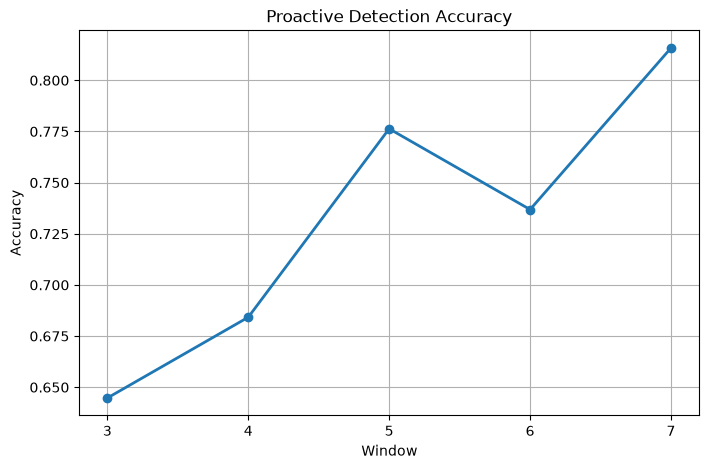

In [53]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Window"],
    results_df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xticks(
    results_df["Window"]
)

plt.grid(True)

plt.title(
    "Proactive Detection Accuracy"
)

plt.xlabel(
    "Window"
)

plt.ylabel(
    "Accuracy"
)

plt.savefig(
    os.path.join(REPO_ROOT, "results/week5/proactive_accuracy.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

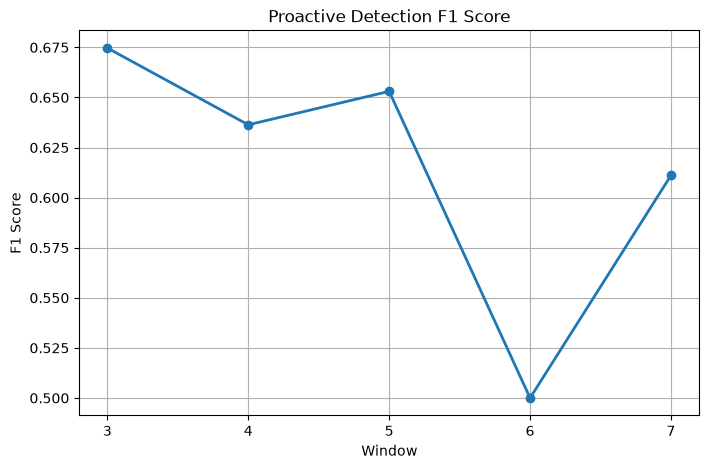

In [54]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Window"],
    results_df["F1"],
    marker="o",
    linewidth=2
)

plt.xticks(
    results_df["Window"]
)

plt.grid(True)

plt.title(
    "Proactive Detection F1 Score"
)

plt.xlabel(
    "Window"
)

plt.ylabel(
    "F1 Score"
)

plt.savefig(
    os.path.join(REPO_ROOT, "results/week5/proactive_f1.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
print(results_df)
import pandas as pd
import os

future_df = pd.concat(
    all_future,
    ignore_index=True
)

future_df["Actual"] = all_true
future_df["Predicted"] = all_pred

os.makedirs(os.path.join(REPO_ROOT, "results/week6"), exist_ok=True)

future_df.to_csv(
    os.path.join(REPO_ROOT, "results/week6/proactive_predictions.csv"),
    index=False
)

   Window  Accuracy  Precision    Recall        F1  Threshold
0       3  0.644737   0.528302  0.933333  0.674699        0.3
1       4  0.684211   0.552632  0.750000  0.636364        0.4
2       5  0.776316   0.800000  0.551724  0.653061        0.5
3       6  0.736842   0.384615  0.714286  0.500000        0.4
4       7  0.815789   0.846154  0.478261  0.611111        0.6


In [56]:
%who

MinMaxScaler	 REPO_ROOT	 X_future	 X_train	 X_val	 acc	 accuracy_score	 all_future	 all_pred	 
all_true	 batch	 batch_size	 batches	 best_f1	 col	 cols_with_missing	 df	 f1	 
f1_score	 future_batch	 future_df	 i	 mean_row	 median_value	 model	 np	 os	 
pd	 plt	 precision	 precision_score	 random	 recall	 recall_score	 results	 results_df	 
results_with_mean	 scaler	 start	 sys	 t	 tf	 threshold	 thresholds_to_try	 train_batches	 
train_df	 val_batch	 val_f1	 y_future	 y_pred	 y_prob	 y_train	 y_val	 y_val_pred	 
y_val_prob	 


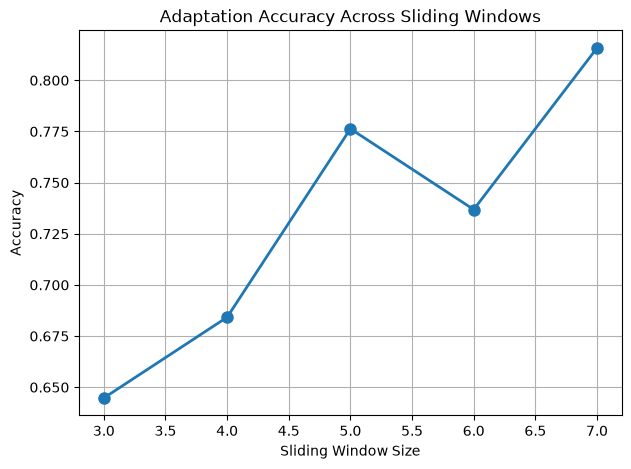

Figure saved successfully.


In [57]:
import matplotlib.pyplot as plt
import os

# Create output folder
os.makedirs("../../results/accuracy", exist_ok=True)

plt.figure(figsize=(7,5))

plt.plot(
    results_df["Window"],
    results_df["Accuracy"],
    marker="o",
    linewidth=2,
    markersize=8
)

plt.xlabel("Sliding Window Size")
plt.ylabel("Accuracy")
plt.title("Adaptation Accuracy Across Sliding Windows")

plt.grid(True)

plt.savefig(
    os.path.join(
        REPO_ROOT,
        "results/accuracy/adaptation_accuracy_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")